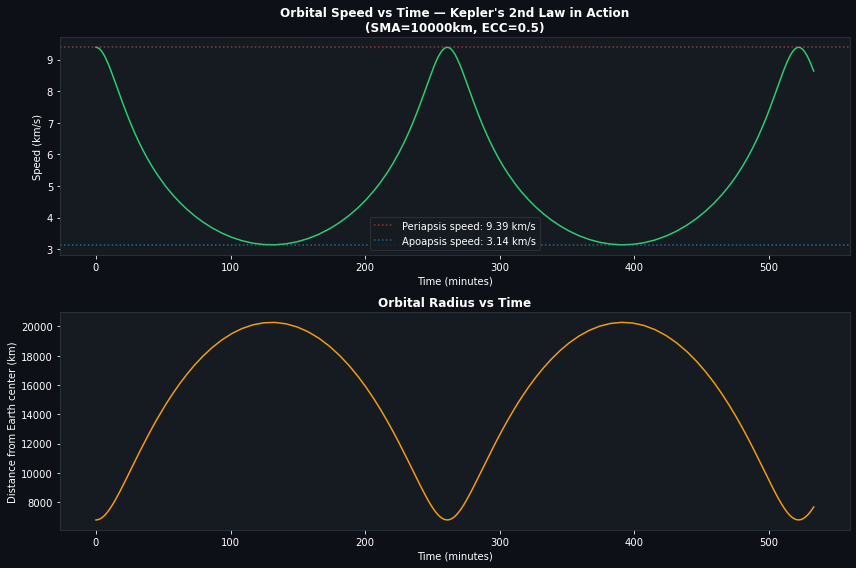

Periapsis speed: 9.392122210234486 km/s
Apoapsis speed: 3.1389745947839023 km/s


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = r'D:\Space Softwares\GMAT Project\Elliptical Orbit + SSO Analysis\Output'

def load_report(filepath, ncols_from_right):
    """Generic GMAT report loader - grabs last N numeric columns."""
    rows = []
    with open(filepath, 'r') as f:
        for line in f.readlines()[1:]:
            parts = line.split()
            if len(parts) < ncols_from_right:
                continue
            rows.append([float(x) for x in parts[-ncols_from_right:]])
    return rows

# Elliptical: ElapsedSecs, RMAG, Lat, Lon, VX, VY, VZ -> last 6 are numeric
data = load_report(os.path.join(output_dir, 'Elliptical_data.txt'), 6)
df = pd.DataFrame(data, columns=['RMAG', 'Lat', 'Lon', 'VX', 'VY', 'VZ'])

# ElapsedSecs is the first column - read separately since it's also numeric but leftmost
rows_full = []
with open(os.path.join(output_dir, 'Elliptical_data.txt'), 'r') as f:
    for line in f.readlines()[1:]:
        parts = line.split()
        if len(parts) >= 7:
            rows_full.append(float(parts[0]))  # ElapsedSecs
df['ElapsedSecs'] = rows_full

df['Speed'] = np.sqrt(df['VX']**2 + df['VY']**2 + df['VZ']**2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), facecolor='#0D1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#161B22')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')

ax1.plot(df['ElapsedSecs']/60, df['Speed'], color='#2ECC71', linewidth=1.5)
ax1.set_xlabel('Time (minutes)', color='white')
ax1.set_ylabel('Speed (km/s)', color='white')
ax1.set_title('Orbital Speed vs Time — Kepler\'s 2nd Law in Action\n(SMA=10000km, ECC=0.5)',
              color='white', fontweight='bold')
ax1.axhline(df['Speed'].max(), color='#E74C3C', linestyle=':', alpha=0.6, label=f'Periapsis speed: {df["Speed"].max():.2f} km/s')
ax1.axhline(df['Speed'].min(), color='#3498DB', linestyle=':', alpha=0.6, label=f'Apoapsis speed: {df["Speed"].min():.2f} km/s')
ax1.legend(facecolor='#161B22', labelcolor='white', edgecolor='#30363D')

ax2.plot(df['ElapsedSecs']/60, df['RMAG'], color='#F39C12', linewidth=1.5)
ax2.set_xlabel('Time (minutes)', color='white')
ax2.set_ylabel('Distance from Earth center (km)', color='white')
ax2.set_title('Orbital Radius vs Time', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'elliptical_velocity_study.png'), dpi=150, facecolor='#0D1117')
plt.show()
print('Periapsis speed:', df['Speed'].max(), 'km/s')
print('Apoapsis speed:', df['Speed'].min(), 'km/s')